<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pr%C3%A1tica2Quest%C3%A3o4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sinal original: fs = 8192 Hz, N = 73113 amostras, duracao = 8.925 s

M = 2: fs_novo = 4096.0 Hz, N_novo = 36557 amostras, Nyquist_novo = 2048.0 Hz
M = 4: fs_novo = 2048.0 Hz, N_novo = 18279 amostras, Nyquist_novo = 1024.0 Hz
M = 8: fs_novo = 1024.0 Hz, N_novo = 9140 amostras, Nyquist_novo = 512.0 Hz


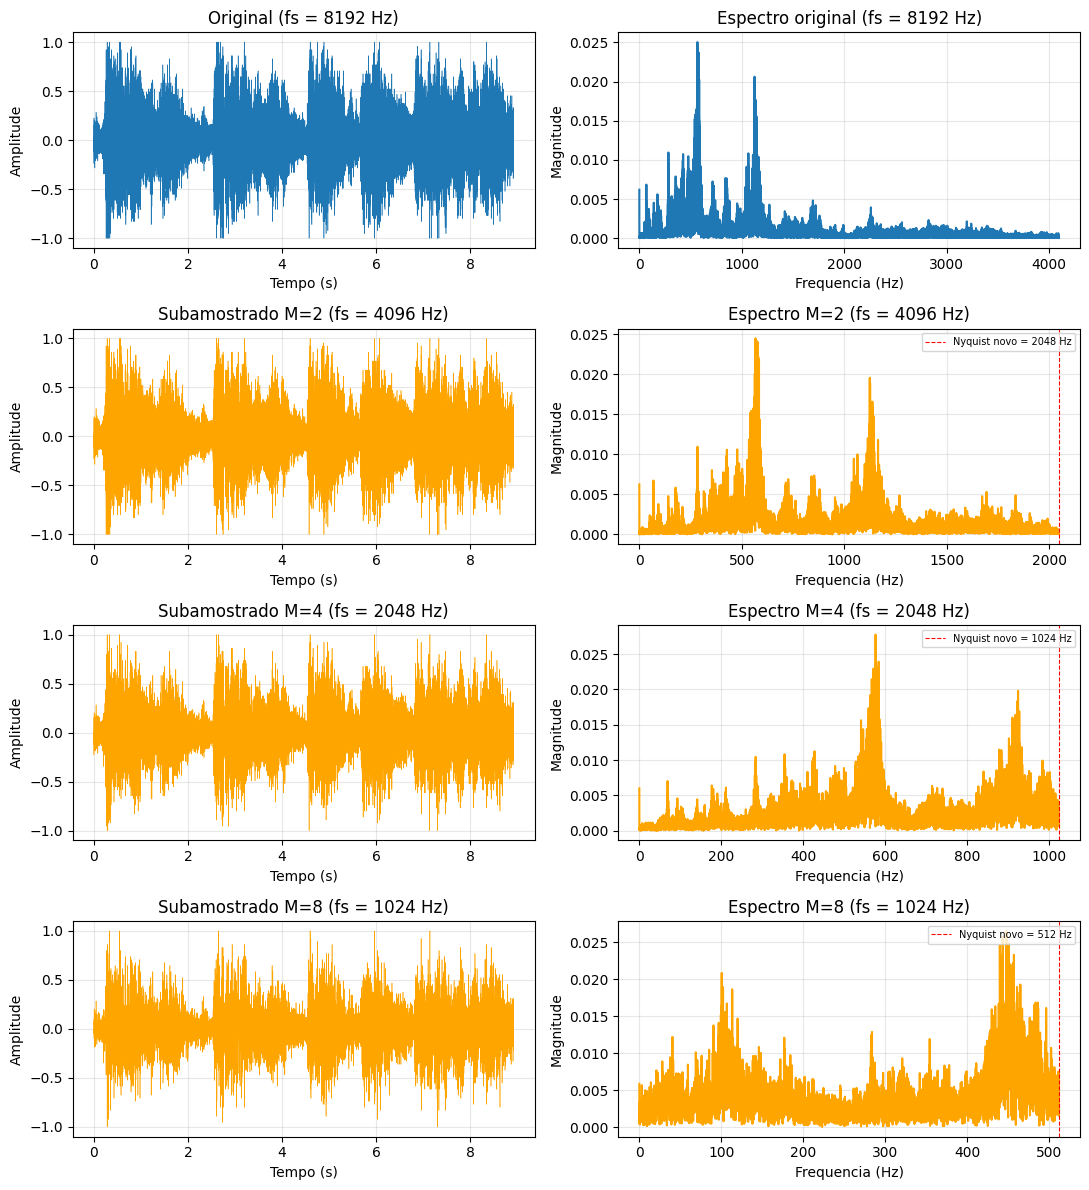

Reproduzindo o audio na frequencia de amostragem original:


--------------------------------------------------
Reproduzindo o audio subamostrado por M=2 (fs = 4096 Hz):


--------------------------------------------------
Reproduzindo o audio subamostrado por M=4 (fs = 2048 Hz):


--------------------------------------------------
Reproduzindo o audio subamostrado por M=8 (fs = 1024 Hz):


--------------------------------------------------

--- Audio subamostrado M=2 (fs = 4096 Hz) ---
Arquivo salvo: handel_subamostrado_M2.wav  (fs = 4096 Hz)



--- Audio subamostrado M=4 (fs = 2048 Hz) ---
Arquivo salvo: handel_subamostrado_M4.wav  (fs = 2048 Hz)



--- Audio subamostrado M=8 (fs = 1024 Hz) ---
Arquivo salvo: handel_subamostrado_M8.wav  (fs = 1024 Hz)


In [3]:
"""
Questao 4 - Subamostragem de um sinal discreto x[n]

Definicao:
    y[n] = x[n*M]

    Ou seja, a subamostragem (downsampling) consiste em pegar apenas
    1 a cada M amostras do sinal original, descartando as demais.
    Isso reduz a taxa de amostragem efetiva de fs para fs/M.

Objetivo:
    (a) Criar uma funcao para realizar a subamostragem de um sinal discreto
    (b) Aplicar a subamostragem ao audio handel.wav para M em {2, 4, 8}
    (c) Calcular o espectro de cada sinal subamostrado (calculate_spectrum)
    (d) Ouvir os sinais subamostrados
    (e) Comentar os resultados obtidos
"""

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import IPython.display as ipd   # usado para ouvir o audio (funciona em Jupyter/Colab)


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.

    Retorna freqs (Hz, parte positiva 0 a fs/2) e mag (magnitude normalizada).
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs_completo = np.fft.fftfreq(N, d=1/fs)
    metade = N // 2
    freqs = freqs_completo[:metade]
    mag = (2.0 / N) * np.abs(X[:metade])
    return freqs, mag


# ---------------------------------------------------------------------------
# (a) Funcao de subamostragem: y[n] = x[n*M]
# ---------------------------------------------------------------------------
def subamostrar(x, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto x[n],
    mantendo apenas 1 a cada M amostras: y[n] = x[n*M].

    Parametros
    ----------
    x : array_like
        Sinal discreto original.
    M : int
        Fator de subamostragem (inteiro >= 1).

    Retorna
    -------
    y : ndarray
        Sinal subamostrado, com aproximadamente N/M amostras.
    """
    # Fatiamento simples: pega os indices 0, M, 2M, 3M, ...
    y = x[::M]
    return y


# ---------------------------------------------------------------------------
# Leitura do arquivo handel.wav (mesmo procedimento da Questao 3)
# ---------------------------------------------------------------------------
usar_colab = True   # mude para False se estiver rodando localmente com o repo clonado

if usar_colab:
    url = ("https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/"
           "main/Aula_02/Sinais_Usados/handel.wav")
    caminho_arquivo = "handel.wav"
    if not os.path.exists(caminho_arquivo):
        print(f"Baixando {caminho_arquivo} de {url} ...")
        urllib.request.urlretrieve(url, caminho_arquivo)
        print("Download concluido.\n")
else:
    caminho_arquivo = "Aula_02/Sinais_Usados/handel.wav"

fs, x = wavfile.read(caminho_arquivo)

if x.ndim > 1:
    x = x[:, 0]

x = x.astype(np.float64)
x = x / np.max(np.abs(x))

N = len(x)
print(f"Sinal original: fs = {fs} Hz, N = {N} amostras, duracao = {N/fs:.3f} s\n")


# ---------------------------------------------------------------------------
# (b) e (c) Subamostragem para M = 2, 4, 8 + calculo do espectro de cada um
# ---------------------------------------------------------------------------
fatores_M = [2, 4, 8]
sinais_subamostrados = {}   # guarda y[n] e fs_novo para cada M (usado no item d)

fig, eixos = plt.subplots(len(fatores_M) + 1, 2, figsize=(11, 12))

# --- Primeira linha: sinal original, para referencia/comparacao ---
freqs_orig, mag_orig = calculate_spectrum(x, fs)
t_orig = np.arange(N) / fs

eixos[0, 0].plot(t_orig, x, linewidth=0.4)
eixos[0, 0].set_title(f"Original (fs = {fs} Hz)")
eixos[0, 0].set_xlabel("Tempo (s)")
eixos[0, 0].set_ylabel("Amplitude")
eixos[0, 0].grid(True, alpha=0.3)

eixos[0, 1].plot(freqs_orig, mag_orig)
eixos[0, 1].set_title(f"Espectro original (fs = {fs} Hz)")
eixos[0, 1].set_xlabel("Frequencia (Hz)")
eixos[0, 1].set_ylabel("Magnitude")
eixos[0, 1].grid(True, alpha=0.3)

# --- Linhas seguintes: um sinal subamostrado para cada M ---
for i, M in enumerate(fatores_M, start=1):

    # (a) Aplica a subamostragem: y[n] = x[nM]
    y = subamostrar(x, M)

    # A nova frequencia de amostragem efetiva cai de fs para fs/M
    fs_novo = fs / M

    # Guarda para uso posterior (item d - ouvir os audios)
    sinais_subamostrados[M] = (y, fs_novo)

    # (c) Calcula o espectro do sinal subamostrado
    freqs, mag = calculate_spectrum(y, fs_novo)

    t_y = np.arange(len(y)) / fs_novo

    print(f"M = {M}: fs_novo = {fs_novo:.1f} Hz, "
          f"N_novo = {len(y)} amostras, "
          f"Nyquist_novo = {fs_novo/2:.1f} Hz")

    # Plot do sinal subamostrado no tempo
    eixos[i, 0].plot(t_y, y, linewidth=0.4, color='orange')
    eixos[i, 0].set_title(f"Subamostrado M={M} (fs = {fs_novo:.0f} Hz)")
    eixos[i, 0].set_xlabel("Tempo (s)")
    eixos[i, 0].set_ylabel("Amplitude")
    eixos[i, 0].grid(True, alpha=0.3)

    # Plot do espectro do sinal subamostrado
    eixos[i, 1].plot(freqs, mag, color='orange')
    eixos[i, 1].set_title(f"Espectro M={M} (fs = {fs_novo:.0f} Hz)")
    eixos[i, 1].set_xlabel("Frequencia (Hz)")
    eixos[i, 1].set_ylabel("Magnitude")
    # Marca onde ficava o limite de Nyquist do sinal ORIGINAL, para
    # visualizar se a nova banda [0, fs_novo/2] ainda cabe dentro dele
    eixos[i, 1].axvline(fs_novo/2, color='r', linestyle='--', linewidth=0.8,
                         label=f"Nyquist novo = {fs_novo/2:.0f} Hz")
    eixos[i, 1].legend(loc="upper right", fontsize=7)
    eixos[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("espectros_subamostragem.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# (d) Ouvir os sinais subamostrados
# ---------------------------------------------------------------------------
# Reproduz o audio original e cada versao subamostrada (M = 2, 4, 8),
# cada uma no seu proprio fs_novo (fs original / M), direto no notebook.

print("Reproduzindo o audio na frequencia de amostragem original:")
ipd.display(ipd.Audio(x, rate=fs, autoplay=False))
print('-' * 50)

for M in fatores_M:
    y, fs_novo = sinais_subamostrados[M]
    print(f"Reproduzindo o audio subamostrado por M={M} (fs = {fs_novo:.0f} Hz):")
    ipd.display(ipd.Audio(y, rate=fs_novo, autoplay=False))
    print('-' * 50)

for M in fatores_M:
    y, fs_novo = sinais_subamostrados[M]
    nome_arquivo = f"handel_subamostrado_M{M}.wav"

    print(f"\n--- Audio subamostrado M={M} (fs = {fs_novo:.0f} Hz) ---")
    salvar_wav(nome_arquivo, y, fs_novo)
    ipd.display(ipd.Audio(y, rate=fs_novo))

Os resultados evidenciam de forma bem clara o efeito da subamostragem (downsampling) sobre um sinal de áudio real, tanto no domínio do tempo quanto no domínio da frequência:

Domínio do tempo — a forma geral da envoltória do sinal (as "rajadas" correspondentes às frases cantadas) se mantém reconhecível em todos os casos (M = 2, 4 e 8), já que a subamostragem não altera a duração total do sinal (ainda são ~8,9 s), apenas reduz o número de amostras usadas para representá-lo. Entretanto, é visível que, quanto maior o M, menos amostras sobram para descrever cada trecho — o sinal fica visivelmente mais "grosseiro" (menos amostras por segundo), especialmente perceptível em M = 8.

Redução proporcional da frequência de amostragem e de Nyquist — como esperado pela relação fs_novo = fs/M, a frequência de Nyquist cai proporcionalmente:

M = 2 → fs_novo = 4096 Hz, Nyquist = 2048 Hz
M = 4 → fs_novo = 2048 Hz, Nyquist = 1024 Hz
M = 8 → fs_novo = 1024 Hz, Nyquist = 512 Hz

Isso reduz cada vez mais a "janela" de frequências que pode ser representada sem distorção.

Efeito de aliasing crescente — este é o ponto mais importante dos resultados:

Em M = 2, o espectro ainda se parece bastante com o original — os dois picos principais (perto de 560 Hz e 1130 Hz) continuam bem definidos, pois a maior parte da energia do sinal original já estava concentrada abaixo de 2048 Hz. A subamostragem aqui causa pouca distorção perceptível.
Em M = 4, os picos começam a se deslocar e se misturar: o segundo pico, que estava em ~1130 Hz no original, aparece agora em torno de ~930 Hz — um deslocamento causado pelo dobramento (fold-back) de componentes de frequência mais alta que ultrapassavam a nova Nyquist (1024 Hz) e foram "refletidas" de volta para dentro da banda representável. O espectro já perde parte da nitidez dos picos originais.
Em M = 8, a distorção é evidente: o espectro perde completamente a semelhança com o original — os picos bem definidos de ~560 Hz e ~1130 Hz desaparecem, dando lugar a um formato completamente diferente, com acúmulo de energia próximo da nova frequência de Nyquist (512 Hz). Isso é o efeito clássico do aliasing severo: múltiplas componentes de frequência distintas do sinal original (bem acima de 512 Hz) foram todas "dobradas" para dentro da faixa [0, 512] Hz, se sobrepondo e corrompendo a informação espectral original de forma irreversível.

Relação com o que se ouve no áudio (item d) — esse comportamento espectral se traduz diretamente na qualidade percebida do áudio: em M = 2, o áudio deve soar praticamente igual ao original (talvez com leve perda de agudos); em M = 4, já é perceptível uma degradação — o som fica mais "abafado" e distorcido; em M = 8, a fala/coral deve ficar praticamente irreconhecível, soando como um ruído grave e embolado, já que grande parte do conteúdo espectral relevante (incluindo a frequência fundamental e seus harmônicos) foi corrompida pelo aliasing.

Conclusão geral — o experimento demonstra na prática que a subamostragem y[n] = x[nM] só preserva fielmente o conteúdo do sinal quando a nova frequência de Nyquist (fs/2M) ainda é maior que a maior componente de frequência relevante do sinal original. Como o áudio handel.wav possui energia espectral distribuída até ~2500 Hz, valores pequenos de M (como M = 2) causam pouca distorção, enquanto valores maiores (M = 4 e principalmente M = 8) violam cada vez mais essa condição, gerando aliasing progressivo — evidenciando, mais uma vez, a importância de um filtro anti-aliasing (passa-baixas) antes de qualquer subamostragem, para eliminar componentes acima da nova Nyquist antes de descartar amostras.